In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [2]:

df = pd.read_csv("Mall_Customers.csv")


In [3]:

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# x = df[['Gender','Age','Annual Income (k$)', 'Spending Score (1-100)']]
# x.head()

In [6]:
num_cols=df.select_dtypes(include='number').columns

In [7]:
preprocessing = ColumnTransformer(
    transformers=[
        ('encoding',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['Gender']),
        ('scaling',StandardScaler(),num_cols)
    ]
)

In [8]:
main_pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', KMeans(n_clusters=2,random_state=42))
    ]
)

In [9]:
main_pipeline.fit(df)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoding', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [10]:
main_pipeline.fit_predict(df)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [11]:
main_pipeline.fit_transform(df)

array([[2.33101815, 3.94965103],
       [2.49306723, 4.05030867],
       [2.73345094, 4.2068501 ],
       [2.233929  , 3.90756149],
       [1.6382302 , 3.66364757],
       [2.23257882, 3.86675955],
       [2.2230715 , 3.97297785],
       [2.56094999, 4.04130246],
       [2.7806892 , 4.50355319],
       [1.76511484, 3.63240088],
       [2.65038365, 4.43379778],
       [2.33582519, 3.96749347],
       [2.14513426, 4.0636658 ],
       [2.06495377, 3.67952372],
       [1.98801938, 3.74673079],
       [2.2597356 , 3.73328071],
       [1.38946615, 3.4313028 ],
       [2.1347821 , 3.60862395],
       [1.62828965, 3.6343176 ],
       [2.2132267 , 3.77177733],
       [1.41823801, 3.32830245],
       [1.92699056, 3.45431806],
       [2.02896815, 3.73747637],
       [1.65838036, 3.34185424],
       [1.8707802 , 3.66612093],
       [1.89466793, 3.37127882],
       [1.15271616, 3.23517128],
       [1.25013044, 3.1129382 ],
       [1.14163742, 3.13647754],
       [2.16598773, 3.44090878],
       [2.

In [12]:
df['Result'] = main_pipeline.predict(df)


In [13]:
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Result
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [14]:
df[df['Result']==0].head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Result
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [15]:
df[df['Result']==1].head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Result
91,92,Male,18,59,41,1
95,96,Male,24,60,52,1
97,98,Female,27,60,50,1
99,100,Male,20,61,49,1
100,101,Female,23,62,41,1


In [16]:
cluster1 = df[df['Result']==1]
cluster0 = df[df['Result']==0]

# Elbow method

In [17]:
import matplotlib.pyplot as plt
metrics_ = []
for cluster in range(1,10):
    main_pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', KMeans(n_clusters=cluster,random_state=42))
    ]
    )

    main_pipeline.fit(df)
    metric = main_pipeline.named_steps['model'].inertia_
    metrics_.append(metric)
    # print(main_pipeline.inertia_).
print(metrics_)

[898.56, 614.0348039103044, 473.6919577957596, 357.54759283135763, 336.6245809100391, 287.6601539596625, 237.41437680842517, 245.3045354050417, 196.86899834730758]


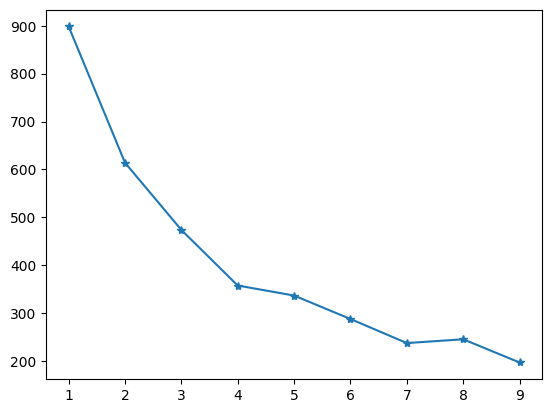

In [18]:
plt.plot(range(1,10),metrics_,marker='*')